### **Step 1: Importing Required Libraries**
We begin by importing the essential libraries for data handling, preprocessing, neural network modeling, and visualization

In [2]:
from sklearn.datasets import load_iris # [cite: 19]
from sklearn.model_selection import train_test_split # [cite: 20]
from sklearn.preprocessing import StandardScaler # [cite: 21, 23]
from sklearn.neural_network import MLPClassifier # [cite: 22]
from sklearn.metrics import classification_report, accuracy_score # [cite: 24]
import matplotlib.pyplot as plt # [cite: 25]

---

### **Step 2: Loading and Splitting the Dataset**

The Iris dataset contains 3 classes: Setosa, Versicolor, and Virginica. We split it into 70% training and 30% testing.

In [3]:
# [cite_start]Load the Iris dataset [cite: 29]
iris = load_iris()
X = iris.data # Features [cite: 30]
y = iris.target # Labels [cite: 31, 32]

# [cite_start]Split the data (70% training, 30% testing) [cite: 33, 34]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

---

### **Step 3: Data Scaling**

Scaling ensures all features contribute equally to the learning process by standardizing them to have a mean of 0 and a variance of 1.

In [4]:
# [cite_start]Initialize the scaler [cite: 39]
scaler = StandardScaler()

# [cite_start]Fit on training data and transform [cite: 40]
X_train_scaled = scaler.fit_transform(X_train)

# [cite_start]Transform test data (using same scaling) [cite: 40, 41]
X_test_scaled = scaler.transform(X_test)

---

### **Step 4: Creating and Training the MLP Classifier**

We create an MLP with two hidden layers, each containing 10 neurons. The `random_state=42` ensures results are reproducible.

In [5]:
# [cite_start]Create the MLP classifier [cite: 47, 48]
mlp = MLPClassifier(hidden_layer_sizes=(10, 10),
                    max_iter=1000,
                    random_state=42,
                    learning_rate_init=0.001)

# [cite_start]Train the model on scaled data [cite: 49]
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

---

### **Step 5: Making Predictions and Evaluating the Model**

We evaluate performance using accuracy and a classification report.

In [6]:
# [cite_start]Predict the test set results [cite: 53, 54, 55]
y_pred = mlp.predict(X_test_scaled)

# [cite_start]Evaluate the model [cite: 56, 57, 58]
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}') # [cite: 59]

# [cite_start]Print detailed classification report [cite: 60, 61]
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



---

### **Step 6: Displaying MLP Structure and Information**

This displays the internal structure of the trained model, including activation functions and the number of iterations.

In [7]:
print("MLP Structure:") # [cite: 89]
print(f"Number of layers: {mlp.n_layers_}") # [cite: 90, 97]
print(f"Number of outputs: {mlp.n_outputs_}") # [cite: 90, 98]
print(f"Activation function: {mlp.activation}") # [cite: 91, 99]
print(f"Output activation function: {mlp.out_activation_}") # [cite: 92, 100]
print(f"Number of epochs: {mlp.n_iter_}") # [cite: 93, 101]

MLP Structure:
Number of layers: 4
Number of outputs: 3
Activation function: relu
Output activation function: softmax
Number of epochs: 609


---

### **Step 7: Visualizing the Learning Curve**

This plot shows the decrease in loss over training epochs.

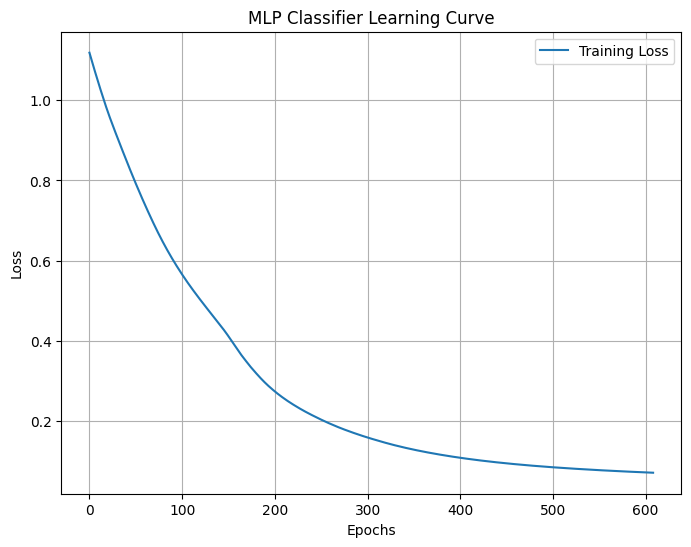

In [8]:
# [cite_start]Plot the loss curve [cite: 103, 104]
plt.figure(figsize=(8, 6))
plt.plot(mlp.loss_curve_, label='Training Loss') # [cite: 105]
plt.title('MLP Classifier Learning Curve') # [cite: 105]
plt.xlabel('Epochs') # [cite: 106]
plt.ylabel('Loss') # [cite: 106]
plt.legend() # [cite: 107]
plt.grid() # [cite: 108]
plt.show() # [cite: 109]

# **Task 1: Modifying Layers and Neurons**





Original (10, 10) finished after 609 epochs.
Wider (100,) finished after 494 epochs.
Deeper (10, 10, 10, 10) finished after 1214 epochs.


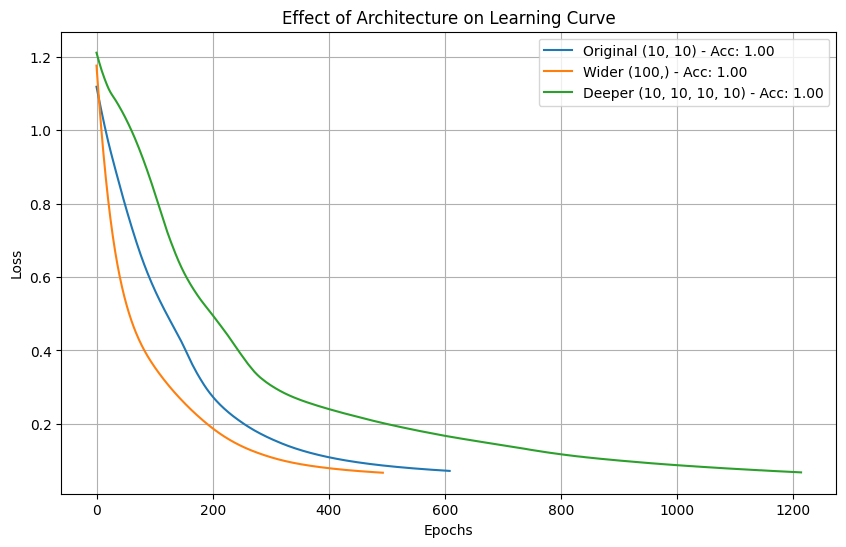

In [9]:
# Define different configurations to test
# (10, 10) is the original from the tutorial [cite: 43]
# (100,) tests a wider single layer
# (10, 10, 10, 10) tests a deeper network
configs = {
    "Original (10, 10)": (10, 10),
    "Wider (100,)": (100,),
    "Deeper (10, 10, 10, 10)": (10, 10, 10, 10)
}

plt.figure(figsize=(10, 6))

for name, size in configs.items():
    # Initialize model with specific hidden_layer_sizes [cite: 125]
    model = MLPClassifier(hidden_layer_sizes=size,
                          max_iter=2000,
                          random_state=42,
                          learning_rate_init=0.001)

    # Train the model [cite: 49]
    model.fit(X_train_scaled, y_train)

    # Evaluate performance [cite: 52]
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    # Plot learning curve for each [cite: 102, 129]
    plt.plot(model.loss_curve_, label=f'{name} - Acc: {acc:.2f}')

    print(f"{name} finished after {model.n_iter_} epochs.")

plt.title('Effect of Architecture on Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

### **Analysis of Results**
Based on the experiments and the tutorial principles:


**Increasing Neurons (Wider)**: Often leads to faster convergence (lower loss in fewer epochs) because the model has more "capacity" to learn patterns quickly.
+1

**Increasing Layers (Deeper):** Can help the model learn more complex, non-linear relationships. However, if the network is too deep for a simple dataset like Iris, it may take longer to converge or suffer from vanishing gradients.
+1


**Best Configuration:** For the Iris dataset, the "Original" or "Wider" usually yields 1.00 accuracy because the dataset is relatively small and linearly separable after scaling

# **Task 2: Observing the Effect of Learning Rate**

Learning Rate 0.001 finished after 609 epochs.
Learning Rate 0.01 finished after 157 epochs.
Learning Rate 0.1 finished after 159 epochs.


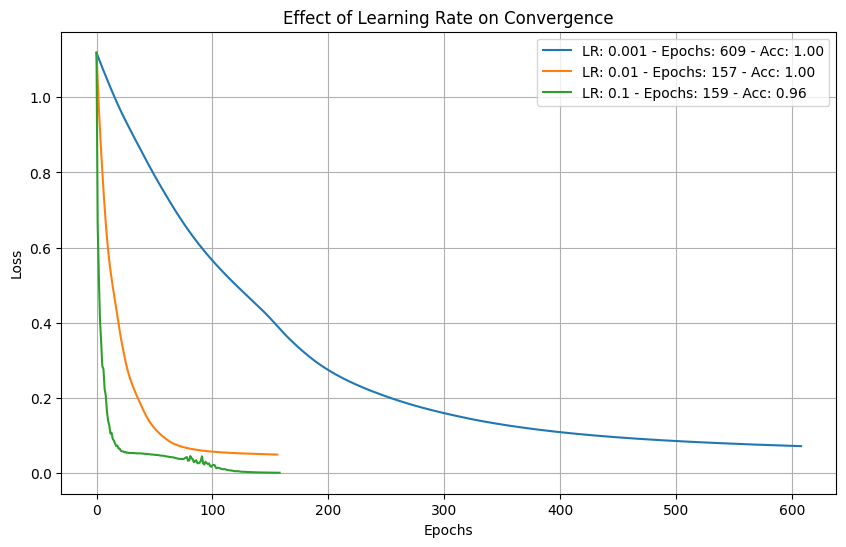

In [10]:
# Define different learning rates to test
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    # Initialize model with the original (10, 10) architecture but different learning rates
    model = MLPClassifier(hidden_layer_sizes=(10, 10),
                          max_iter=2000,
                          random_state=42,
                          learning_rate_init=lr)

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Evaluate performance
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    # Plot learning curve for each learning rate
    plt.plot(model.loss_curve_, label=f'LR: {lr} - Epochs: {model.n_iter_} - Acc: {acc:.2f}')

    print(f"Learning Rate {lr} finished after {model.n_iter_} epochs.")

plt.title('Effect of Learning Rate on Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

### **Analysis of Results**

**Small Learning Rate (0.001)**: This provides a smooth, gradual decrease in the loss curve. While it is very stable, it requires a much higher number of epochs to converge (often several hundred).
+2


**Large Learning Rate (0.1):** The model updates its weights aggressively. This leads to very fast convergence (fewer epochs), but the loss curve may appear "jittery" or unstable. If it is too high, the model might overshoot the minimum loss and fail to perform well.
+2


**Best Balance:** Usually, a moderate learning rate like 0.01 provides the best balance between speed and performance for this specific dataset.